# Часть 1. Проверка гипотезы в Python и составление аналитической записки

Вы предобработали данные в SQL, и теперь они готовы для проверки гипотезы в Python. Загрузите данные пользователей из Москвы и Санкт-Петербурга c суммой часов их активности из файла yandex_knigi_data.csv. Если работаете локально, скачать файл можно по ссылке.

Проверьте наличие дубликатов в идентификаторах пользователей. Сравните размеры групп, их статистики и распределение.

Напомним, как выглядит гипотеза: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

Нулевая гипотеза $H_0: \mu_{\text{СПб}} \leq \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге не больше, чем в Москве.

Альтернативная гипотеза $H_1: \mu_{\text{СПб}} > \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

По результатам анализа данных подготовьте аналитическую записку, в которой опишите:

Выбранный тип t-теста и уровень статистической значимости.

Результат теста, или p-value.

Вывод на основе полученного p-value, то есть интерпретацию результатов.

Одну или две возможные причины, объясняющие полученные результаты.

## Анализ активности пользователей в сервисе Яндекс Книги

- Автор: Алёна Опольская
- Дата: 07.04.2026

## Цели и задачи проекта

Цель проекта - проверить гипотезу о том, что пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в Яндекс Книги, чем пользователи из Москвы. 

Задачи:
- изучить данные пользователей из Москвы и СПб с их активностью (сумма часов чтения и прослушивания);
- провести исследовательский анализ данных;
- оценить и сравнить размеры групп, их описательные статистики и распределение данных;
- провести статистический тест;
- сделать выводы по выдвинутой гипотезе.

## Описание данных

Данные о пользователях представлены следующим образом:
- город;
- идентификатор пользователя;
- сумма часов чтения и прослушивания.

## Содержимое проекта

1. Загрузка данных и первичный анализ (проверка на дубликаты, сравнение размеров групп, их статистик и распределения).
2. Проверка гипотезы с использованием статистического теста.
3. Аналитическая записка (выводы). 

## 1. Загрузка данных и знакомство с ними

Загрузите данные пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания) из файла `/datasets/yandex_knigi_data.csv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/datasets/yandex_knigi_data.csv')
df.head()

,Unnamed: 0,city,puid,hours
0,0,Москва,9668,26.167776
1,1,Москва,16598,82.111217
2,2,Москва,80401,4.656906
3,3,Москва,140205,1.840556
4,4,Москва,248755,151.326434


In [3]:
df = df.drop(columns=['Unnamed: 0'])
df.head()

,city,puid,hours
0,Москва,9668,26.167776
1,Москва,16598,82.111217
2,Москва,80401,4.656906
3,Москва,140205,1.840556
4,Москва,248755,151.326434


In [4]:
df['puid'].duplicated().sum()

244

Найдено 244 дубликата в идентификаторах пользователя. Посмотрим что это за дубликаты.

In [5]:
df[df['puid'].duplicated(keep=False)].sort_values('puid')

,city,puid,hours
35,Москва,2637041,10.317371
6247,Санкт-Петербург,2637041,3.883926
134,Москва,9979490,32.415573
6274,Санкт-Петербург,9979490,1.302997
145,Москва,10597984,42.931506
...,...,...,...
6195,Москва,1130000020425037,0.310556
8775,Санкт-Петербург,1130000023864516,14.384722
6202,Москва,1130000023864516,142.830085
6210,Москва,1130000028554332,11.277554


Мы видим, что дубликаты появились из-за того, что один пользователь читает и из Москвы, и из Санкт-Петербурга. Для проведения t-теста группы должны быть независимыми, поэтому данные нужно обработать - оставим только 1 город на каждого пользователя (тот, где количество часов выше - примем его за "основной" город для данного пользователя). После этого еще раз проверим данные на наличие дубликатов в идентификаторах пользователей.

In [6]:
df = df.sort_values('hours', ascending=False).drop_duplicates(subset='puid')
df['puid'].duplicated().sum()

0

С дубликатами разобрались. Теперь сравним группы по размеру.

In [7]:
df_moscow = df[df['city']=='Москва']
df_spb = df[df['city']=='Санкт-Петербург']
print(f'Количество пользователей из Москвы: {len(df_moscow)}')
print(f'Количество пользователей из Санкт-Петербурга: {len(df_spb)}')

Количество пользователей из Москвы: 6099
Количество пользователей из Санкт-Петербурга: 2441


In [8]:
df_moscow['hours'].describe()

count    6099.000000
mean       11.075176
std        37.229705
min         0.000022
25%         0.058889
50%         0.930357
75%         6.025852
max       857.209373
Name: hours, dtype: float64

In [9]:
df_spb['hours'].describe()

count    2441.000000
mean       12.028376
std        40.521834
min         0.000025
25%         0.075278
50%         1.025801
75%         6.880545
max       978.764775
Name: hours, dtype: float64

В обеих группах среднее значение сильно выше медианы, а значит данные ассимметричны - в обеих группах присутствуют пользователи с очень высоким количеством часов активности. Это подтверждает и очень большая разница между значениями 75 квантиля и max значениями.

Посмотрим на распределение данных на графиках.

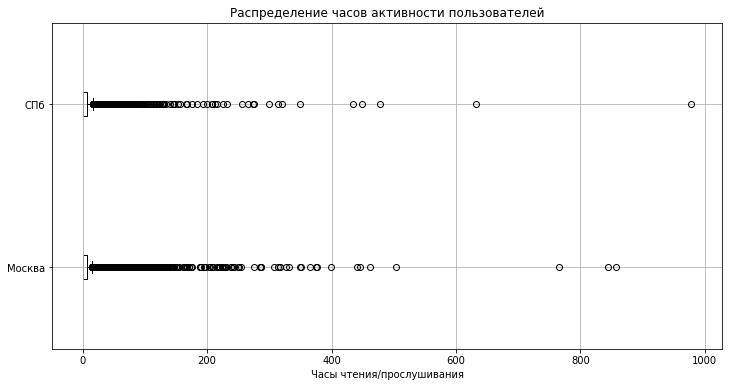

In [10]:
plt.figure(figsize=(12, 6))
plt.boxplot(
    [df_moscow['hours'], df_spb['hours']],
    vert=False
)
plt.yticks([1, 2], ['Москва', 'СПб'])
plt.xlabel('Часы чтения/прослушивания')
plt.title('Распределение часов активности пользователей')
plt.grid(True)
plt.show()

Мы видим, что, в целом, группы похожи между собой - длинные усы справа (наличие выбросов с большим количеством часов), короткие ящики, медиана - около 1 часа (но ранее мы видели, что у СПб она чуть выше: 1,03 СПб и 0,93 Москва, возможно в среднем пользователи СПб, действительно, более активны в приложении - проверим гипотезу дальше).

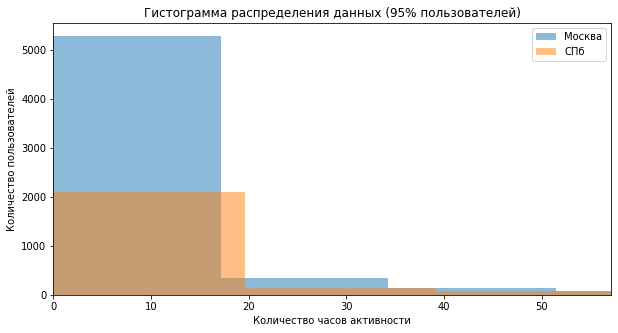

In [11]:
plt.figure(figsize=(10,5))
plt.hist(df_moscow['hours'], bins=50, alpha=0.5, label='Москва')
plt.hist(df_spb['hours'], bins=50, alpha=0.5, label='СПб')
up_lim = df['hours'].quantile(0.95)
plt.xlim(0, up_lim)
plt.legend()
plt.xlabel('Количество часов активности')
plt.ylabel('Количество пользователей')
plt.title('Гистограмма распределения данных (95% пользователей)')
plt.show()

Для того, чтобы гистограмма была более читаема, мы построили ее на основе данных большинства (95%) пользователей, тем самым ограничив диапазон значений по оси X. На гистограмме видим, что распределение пользователей из Санкт-Петербурга немного смещено вправо по сравнению с Москвой, что может предполагать более длительную активность пользователей СПб.

Распределения в обеих группах не симметричны (имеют хвосты справа и содержат выбросы). Размеры групп тоже различаются, но это не является проблемой - мы будем использовать t-тест Уэлча, который более устойчив к различиям между группами и не требует равенства дисперсий. Дополнительно проведем тест Манна-Уитни, т к наши данные все же содержат выбросы. Удалять выбросы не будем, т к они представляют реальное поведение пользователей.

## 2. Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

Проводим тест Уэлча.

In [12]:
from scipy import stats as st

result = st.ttest_ind(
df_spb['hours'],
df_moscow['hours'],
equal_var=False,
alternative='greater'
)
print(result.pvalue)

alpha=0.05

if result.pvalue>alpha:
    print(f'pvalue={result.pvalue} > {alpha}')
    print('Нулевая гипотеза не отвергнута!')
else:
    print(f'pvalue={result.pvalue} < {alpha}')
    print('Нулевая гипотеза отвергнута!')

0.15752715242320128
pvalue=0.15752715242320128 > 0.05
Нулевая гипотеза не отвергнута!


P-value (0.158) больше уровня значимости (0.05), поэтому нет оснований отвергнуть нулевую гипотезу.
Статистически значимых различий в средней активности пользователей Санкт-Петербурга и Москвы не выявлено.

Теперь проведем тест Манна-Уитни.

In [13]:
from scipy import stats as st

mw_result = st.mannwhitneyu(
    df_spb['hours'],
    df_moscow['hours'],
    alternative='greater'
)
print(mw_result.pvalue)

alpha=0.05

if mw_result.pvalue>alpha:
    print(f'pvalue={mw_result.pvalue} > {alpha}')
    print('Нулевая гипотеза не отвергнута!')
else:
    print(f'pvalue={mv_result.pvalue} < {alpha}')
    print('Нулевая гипотеза отвергнута!')

0.06159915490740047
pvalue=0.06159915490740047 > 0.05
Нулевая гипотеза не отвергнута!


Согласно результату теста Манна-Уитни, P-value (0.06) тоже больше уровня значимости (0.05), поэтому нет оснований отвергнуть нулевую гипотезу.

## 3. Аналитическая записка
По результатам анализа данных подготовьте аналитическую записку, в которой опишете:

- Выбранный тип t-теста и уровень статистической значимости.

- Результат теста, или p-value.

- Вывод на основе полученного p-value, то есть интерпретацию результатов.

- Одну или две возможные причины, объясняющие полученные результаты.



В рамках теста мы проверили следующую гипотезу: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы.

Сначала мы обработали данные:
- обнаружили и устранили дубликаты (для каждого пользователя оставили основной город - город с наибольшим временем активности);
- провели сравнение размера групп: пользователей из Москвы больше, чем пользователей из Санкт-Петербурга (6099 и 2441 соответственно);
- изучили статистики и распределение данных обеих групп и выявили, что распределение данных в обеих группах асимметрично и содержит высокие выбросы (большое кол-во часов активности у отдельных пользователей). Медиана - около 1 часа (но у пользователей СПб она чуть выше: 1,03 СПб и 0,93 Москва).

Далее мы проверили гипотезу с помощью t-тест Уэлча, установленный уровень значимости = 0.05. 
На старте теста гипотезы звучали так:
H0: среднее время активности пользователей из Москвы и из Санкт-Петербура не различается.
H1: среднее время активности пользователей Санкт-Петербурга выше, и это различие статистически значимо.

Нами было получено значение p-value = 0.158, что превышает уровень значимости. В связи с этим, основанией отвергнуть нулевую гипотезу нет. Статистически значимых различий в среднем времени активности пользователей Санкт-Петербурга и Москвы не обнаружено. 

Стоит отметить, что в данных обеих групп присутствуют выбросы - пользователи с очень высоким временем активности, что увеличивает разброс значений. Также группы сильно различаются по размеру. При этом есть небольшая разница средних значений между группами. Это могло повлиять на результаты теста.

Для дополнительной проверки результатов мы провели непараметрический тест Манна–Уитни, который не требует предположения о нормальности распределения. В результате получили значение p-value = 0.062, что также превышает уровень значимости 0.05. Статистически значимых различий между активностью пользователей из Иосквы м СПб не выявлено. 

А значит, нельзя утверждать, что пользователи Санкт-Петербурга в среднем проводят больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы.

----

# Часть 2. Анализ результатов A/B-тестирования

Теперь вам нужно проанализировать другие данные. Представьте, что к вам обратились представители интернет-магазина BitMotion Kit, в котором продаются геймифицированные товары для тех, кто ведёт здоровый образ жизни. У него есть своя целевая аудитория, даже появились хиты продаж: эспандер со счётчиком и напоминанием, так и подстольный велотренажёр с Bluetooth.

В будущем компания хочет расширить ассортимент товаров. Но перед этим нужно решить одну проблему. Интерфейс онлайн-магазина слишком сложен для пользователей — об этом говорят отзывы.

Чтобы привлечь новых клиентов и увеличить число продаж, владельцы магазина разработали новую версию сайта и протестировали его на части пользователей. По задумке, это решение доказуемо повысит количество пользователей, которые совершат покупку.

Ваша задача — провести оценку результатов A/B-теста. В вашем распоряжении:

* данные о действиях пользователей и распределении их на группы,

* техническое задание.

Оцените корректность проведения теста и проанализируйте его результаты.

## 1. Опишите цели исследования.



Цель данного исследования - проанализировать результат A/B теста и сделать вывод: действительно ли новая версия интерфейса онлайн-магазина BitMotion Kit помогает увеличить конверсию из пользователей в покупателей. Ожидаемый результат: с новым интерфейсом (дизайном сайта) в течение 7 дней после регистрации в системе конверсия зарегистрированных пользователей в покупателей увеличится как минимум на 3 процентных пункта.

## 2. Загрузите данные, оцените их целостность.


In [14]:
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

In [15]:
participants.head()

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


Мы видим, что помимо interface_eu_test в данних есть еще другие тесты - посмотрим какие.

In [16]:
participants['ab_test'].value_counts()

interface_eu_test          10850
recommender_system_test     3675
Name: ab_test, dtype: int64

В данных содержатся результаты не только теста нового дизайна сайта, но и тест новой рекомендательной системы. Мы не знаем когда проводился этот тест, и если предположить, что в одно время, то пользователи, которые участвовали в обоих тестах могут исказить результаты, ведь мы не знаем что в итоге дало эффект - новый интерфейс или обновленная рекомендательная система. Нужно проверить сколько таких пользователей.

In [17]:
users_both_tests = participants.groupby('user_id')['ab_test'].nunique().reset_index()
users_both_tests = users_both_tests[users_both_tests['ab_test']>1]
users_both_tests_share = round(users_both_tests['user_id'].nunique()/participants['user_id'].nunique()*100,2)
print(f'Доля пользователей, которые участвуют в 2 тестах = {users_both_tests_share}%')

Доля пользователей, которые участвуют в 2 тестах = 6.5%


Для чистоты результатов эксперимента, мы исключим таких пользователей из данных, т к их поведение может быть обосновано не только тестом нового дизайна сайта. 

In [18]:
id_both_tests = users_both_tests['user_id']
participants_clean = participants[~participants['user_id'].isin(id_both_tests)]

Согласно ТЗ в рамках анализа нас интересует только тест с полным обновлением дизайна сайта (interface_eu_test), поэтому оставим только данные по этому тесту.

In [19]:
new_participants = participants_clean[participants_clean['ab_test']=='interface_eu_test']
new_participants.head()

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
4,001E72F50D1C48FA,A,interface_eu_test,Mac
5,002412F1EB3F6E38,B,interface_eu_test,Mac
6,002540BE89C930FB,B,interface_eu_test,Android
7,0031F1B5E9FBF708,A,interface_eu_test,Android


Теперь проверим дубликаты user_id, чтобы исключить ситуацию, что один пользователь вошел в обе группы. 

In [20]:
user_dupli = new_participants.groupby('user_id')['group'].nunique().value_counts()
user_dupli

1    9963
Name: group, dtype: int64

Пользователей, которые попали в обе группы (А и В) не обнаружено. Всего остались данные о 9963 пользователях, каждый из которых выходит в одну группу.

Проверим пропуски и дубликаты в данных.

In [21]:
new_participants.isna().sum()

user_id    0
group      0
ab_test    0
device     0
dtype: int64

In [22]:
new_participants.duplicated().sum()

0

In [23]:
new_participants.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9963 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  9963 non-null   object
 1   group    9963 non-null   object
 2   ab_test  9963 non-null   object
 3   device   9963 non-null   object
dtypes: object(4)
memory usage: 389.2+ KB


Теперь перейдем к знакомству с events.

In [24]:
events.head()

,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


Сначала оставим здесь только нужных пользователей (new_participants).

In [25]:
new_events = events[events['user_id'].isin(new_participants['user_id'])]
new_events.head()

,user_id,event_dt,event_name,details
64672,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0
64946,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8
66585,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32
67873,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48
67930,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0


In [26]:
print(f"Количество пользователей до фильтрации:{events['user_id'].nunique()}")
print(f"Количество пользователей после фильтрации:{new_events['user_id'].nunique()}")

Количество пользователей до фильтрации:144184
Количество пользователей после фильтрации:9963


После фильтрации с данных осталось 9963 пользователей, что соответствует кол-ву участников теста.

Проверим пропуски и дубликаты в данных.

In [27]:
new_events.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 73815 entries, 64672 to 780371
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     73815 non-null  object        
 1   event_dt    73815 non-null  datetime64[ns]
 2   event_name  73815 non-null  object        
 3   details     19450 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 2.8+ MB


In [28]:
new_events['event_name'].value_counts()

login           27360
product_page    17614
registration     9963
purchase         9487
product_cart     9391
Name: event_name, dtype: int64

In [29]:
new_events.isna().sum()

user_id           0
event_dt          0
event_name        0
details       54365
dtype: int64

Пропуски обнаружены только в столбце details - это ОК, учитывая, что это дополнительная информация.

In [30]:
new_events.duplicated().sum()

5741

Посмотрим что это за дубликаты.

In [31]:
events_dupli = new_events[new_events.duplicated(keep=False)]
events_dupli = events_dupli.sort_values(['user_id', 'event_dt'])
events_dupli.head(10)

,user_id,event_dt,event_name,details
505926,002412F1EB3F6E38,2020-12-20 01:35:41,product_page,NaN
505927,002412F1EB3F6E38,2020-12-20 01:35:41,product_page,NaN
124352,002540BE89C930FB,2020-12-08 18:06:07,login,NaN
124353,002540BE89C930FB,2020-12-08 18:06:07,login,NaN
124355,002540BE89C930FB,2020-12-08 18:06:07,login,NaN
226536,002540BE89C930FB,2020-12-12 05:49:48,product_page,NaN
226537,002540BE89C930FB,2020-12-12 05:49:48,product_page,NaN
348507,0053DD654C9513D6,2020-12-15 08:46:21,purchase,4.99
348508,0053DD654C9513D6,2020-12-15 08:46:21,purchase,4.99
640673,005881C49580D705,2020-12-23 13:55:37,login,NaN


Дубликаты технические - один и тот же пользователь совершает одно и то же действие в одно и то же время. Такие дубликаты можем удалять.

In [32]:
new_events = new_events.drop_duplicates()
new_events.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 68074 entries, 64672 to 780371
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     68074 non-null  object        
 1   event_dt    68074 non-null  datetime64[ns]
 2   event_name  68074 non-null  object        
 3   details     18864 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 2.6+ MB


В ходе знакомства с данными participants и их предобработки:
- отфильтровали данные по интересующему нас тесту;
- исключили пользователей, которые участвовали в нескольких тестах;
- провели проверку пользователей на участие только в одной группе эксперимента;
- проверили на наличие пропусков и дубликатов.
Сейчас датасет соержит данные о 9963 пользователях. 

В ходе знакомства с данными events и их предобработки:
- оставили только пользователей, которые участвуют в тесте (9963);
- проверили пропуски (есть только в details);
- проверили на наличие дубликатов и удалили технические дубликаты.

## 3. По таблице `ab_test_participants` оцените корректность проведения теста:

   3\.1 Выделите пользователей, участвующих в тесте, и проверьте:

   - соответствие требованиям технического задания,

   - равномерность распределения пользователей по группам теста,

   - отсутствие пересечений с конкурирующим тестом (нет пользователей, участвующих одновременно в двух тестовых группах).

Выше мы уже выделили пользователей, которые участвуют в нужном нам тесте и проверили на пересечение с другим тестом + на учсастие в двух группах одновременно. Будем использовать эти "чистые" данные и проверим равномерность распределния пользователей по группам теста.

In [33]:
ab_test_participants = new_participants
ab_test_participants.head()

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
4,001E72F50D1C48FA,A,interface_eu_test,Mac
5,002412F1EB3F6E38,B,interface_eu_test,Mac
6,002540BE89C930FB,B,interface_eu_test,Android
7,0031F1B5E9FBF708,A,interface_eu_test,Android


In [34]:
ab_test_participants.groupby('group')['user_id'].nunique()

group
A    4952
B    5011
Name: user_id, dtype: int64

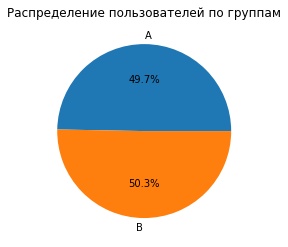

In [35]:
import matplotlib.pyplot as plt

plt.figure()
plt.pie(ab_test_participants.groupby('group')['user_id'].nunique(),
       labels=['A','B'],
       autopct='%1.1f%%')
plt.title('Распределение пользователей по группам')
plt.show()

Пользователи распределны по группам А и В корректно. Разница незначительная (менее 1%).

3\.2 Проанализируйте данные о пользовательской активности по таблице `ab_test_events`:

- оставьте только события, связанные с участвующими в изучаемом тесте пользователями;

Сделала в ходе предобработки. Будем использовать эти "чистые" данные.

In [36]:
ab_test_events = new_events 
ab_test_events.head()

,user_id,event_dt,event_name,details
64672,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0
64946,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8
66585,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32
67873,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48
67930,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0


- определите горизонт анализа: рассчитайте время (лайфтайм) совершения события пользователем после регистрации и оставьте только те события, которые были выполнены в течение первых семи дней с момента регистрации;

In [37]:
#Выделим дату регистрации для каждого пользователя
reg_events = ab_test_events[ab_test_events['event_name']=='registration'][['user_id','event_dt']]
reg_events = reg_events.rename(columns={'event_dt':'reg_dt'})
ab_test_events = ab_test_events.merge(reg_events, on='user_id', how='left')
ab_test_events.sort_values(['user_id','event_dt']).head(6)

,user_id,event_dt,event_name,details,reg_dt
513,0002CE61FF2C4011,2020-12-07 04:37:31,registration,-2.38,2020-12-07 04:37:31
514,0002CE61FF2C4011,2020-12-07 04:37:49,login,NaN,2020-12-07 04:37:31
515,0002CE61FF2C4011,2020-12-07 04:37:57,login,NaN,2020-12-07 04:37:31
517,0002CE61FF2C4011,2020-12-07 04:38:54,login,NaN,2020-12-07 04:37:31
4587,0002CE61FF2C4011,2020-12-08 22:15:35,login,NaN,2020-12-07 04:37:31
4590,0002CE61FF2C4011,2020-12-08 22:15:36,product_page,NaN,2020-12-07 04:37:31


In [38]:
#Посчитаем время совершения события и отфильтруем (первые 7 дней после регистрации)
ab_test_events['lifetime'] = ab_test_events['event_dt']-ab_test_events['reg_dt']
ab_test_events = ab_test_events[ab_test_events['lifetime']<= pd.Timedelta(days=7)]
ab_test_events.sort_values(['user_id','event_dt']).head(6)

,user_id,event_dt,event_name,details,reg_dt,lifetime
513,0002CE61FF2C4011,2020-12-07 04:37:31,registration,-2.38,2020-12-07 04:37:31,0 days 00:00:00
514,0002CE61FF2C4011,2020-12-07 04:37:49,login,NaN,2020-12-07 04:37:31,0 days 00:00:18
515,0002CE61FF2C4011,2020-12-07 04:37:57,login,NaN,2020-12-07 04:37:31,0 days 00:00:26
517,0002CE61FF2C4011,2020-12-07 04:38:54,login,NaN,2020-12-07 04:37:31,0 days 00:01:23
4587,0002CE61FF2C4011,2020-12-08 22:15:35,login,NaN,2020-12-07 04:37:31,1 days 17:38:04
4590,0002CE61FF2C4011,2020-12-08 22:15:36,product_page,NaN,2020-12-07 04:37:31,1 days 17:38:05


Оцените достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%.

In [39]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

effect_size = proportion_effectsize(0.30, 0.33) #по тех заданию на 3 процентных пункта
analysis = NormalIndPower()
sample_size = analysis.solve_power(
    effect_size = effect_size,
    power = 0.8,
    alpha = 0.05,
    ratio = 1)
print(round(sample_size))

3762


Минимально необходимый размер выборки для каждой группы: 3762 пользователя. В группе A: 4952, в группе B: 5011 пользователей. Значит выборка достаточна для получения статистически значимых результатов A/B теста.

- рассчитайте для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

In [40]:
ab_test_events = ab_test_events.merge(ab_test_participants[['user_id', 'group']], on='user_id', how='left')
users_in_group = ab_test_participants.groupby('group')['user_id'].nunique()
buyers_in_group = ab_test_events[ab_test_events['event_name']=='purchase'].groupby('group')['user_id'].nunique()
n_a = users_in_group['A']
n_b = users_in_group['B']
m_a = buyers_in_group['A']
m_b = buyers_in_group['B']
print(f'Из {n_a} пользователей группы А, {m_a} пользователей совершили покупку ({round(m_a/n_a*100,2)}%).')
print(f'Из {n_b} пользователей группы B, {m_b} пользователей совершили покупку ({round(m_b/n_b*100,2)}%).')

Из 4952 пользователей группы А, 1377 пользователей совершили покупку (27.81%).
Из 5011 пользователей группы B, 1480 пользователей совершили покупку (29.54%).


- сделайте предварительный общий вывод об изменении пользовательской активности в тестовой группе по сравнению с контрольной.

Конверсия в покупателей в тестовой группе B выше, но разница составляет 1.73 процентных пункта. Наш ожидаемый результат - минимум 3 процентных пункта. Значит мы можем предположить, что изменение дизайна сайта повлияло на конверсию положительно, но не значительно. 

## 4. Проведите оценку результатов A/B-тестирования:

- Проверьте изменение конверсии подходящим статистическим тестом, учитывая все этапы проверки гипотез.

Нулевая гипотеза (H0): конверсия зарегистрированных пользователей в покупателей в группе А и B равна.

Альтернативная гипотеза (H1): конверсия зарегистрированных пользователей в покупателей в группе B выше, чем в группе A, минимум на 3 процентных пункта.

Ключевая метрика: конверсия из зарегистрированных пользователей в покупателей.
В качестве вспомогательных метрик можно было бы выбрать: средний чек и среднюю стоимость привлечения клиента.
В качестве барьерной: общее количество зарегистрированных пользователей (чтобы проверить, что новый интерфейс не стал неудобнее для пользователей в вопросе регистрации на сайте). 

In [41]:
from statsmodels.stats.proportion import proportions_ztest

alpha =  0.05
stat_ztest, p_value_ztest = proportions_ztest(
        [m_b, m_a],
        [n_b, n_a],
        alternative='larger')

print(f'pvalue={p_value_ztest}')

if p_value_ztest > alpha:
    print('Нулевая гипотеза находит подтверждение!')
else:
    print('Нулевая гипотеза не находит подтверждения!')

pvalue=0.028262547212292124
Нулевая гипотеза не находит подтверждения!


- Опишите выводы по проведённой оценке результатов A/B-тестирования. Что можно сказать про результаты A/B-тестирования? Был ли достигнут ожидаемый эффект в изменении конверсии?

В результате Z-теста пропорций p-value ниже уровня значимости, а значит есть основания отвергнуть нулевую гипотезу о равенстве конверсий в контрольной и тестовой группах. Повышение конверсии в тестовой группе является статистически значимым, но абсолютное значение роста показателя (1.73 процентных пункта) ниже ожидаемого (минимум 3 процентных пункта). Таким образом можно сказать, что изменение интерфейса сайта оказало значимое влияние на конверсию из пользователей в покупателей, но эффект слабее ожидаемого.

В целях улучшения конверсии в покупателей, можно поработать со следующими рекомендациями:
- дополнительно проанализировать воронку (путь пользователей от попадания на сайт до совершения покупки), чтобы найти ключевые этапы, где происходит наибольший отток пользователей - эти этапы нужно упростить с точки зрения интерфейса в первую очередь;
- протестировать альтернативные изменения интерфейса (например, еще больше упрощённые формы или дополнительные подсказки), чтобы достичь более значимого роста конверсии;
- можно рассмотреть поведение пользователей с учетом сегментации по устройствам и по регионам - возможно поведение будет сильно различаться и найдутся новые инсайты;
- проанализировать данные по тесту рекомендательной системы: чем точнее рекомендации (например, сопутствующие товары) попадают в "интерес" пользователя, тем выше шанс увеличить средний чек покупки.